In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")

from BIGFAM import obj2, tools
import importlib

In [2]:
# load FR-reg
frreg_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/frreg/REL"
fns = os.listdir(frreg_path)
len(fns)

40

# Step 1. How does `FRreg` looks like

In [3]:
fn = "QTC_interval.REL.frreg"
df_frreg = pd.read_csv(f"{frreg_path}/{fn}", sep='\t')
df_frreg

,DOR,relationship,sex_type,Erx,slope,se,p,n
0,1,DF,FM,0.707107,-0.007620,0.015424,6.213264e-01,4204
1,1,DM,FF,0.500000,0.099145,0.012084,2.742952e-16,6782
2,1,DS,FF,0.750000,0.182804,0.012495,1.120786e-47,6192
3,1,SB,MM,0.500000,-0.003712,0.018598,8.418275e-01,2892
4,1,SF,MM,0.000000,0.137508,0.017080,1.130428e-15,3364
...,...,...,...,...,...,...,...,...
61,3,SM_DS_DM,FM,0.265165,-0.018631,0.048385,7.003792e-01,428
62,3,SM_DS_SM,MM,0.375000,0.098918,0.058944,9.441338e-02,286
63,3,SM_SM_SF,MM,0.000000,0.259980,0.291144,3.909943e-01,12
64,3,SM_SS_DB_DF,FM,0.176777,-0.031861,0.063855,6.182534e-01,246


In [4]:
df_frreg.groupby("DOR").mean()

,Erx,slope,se,p,n
DOR,,,,,
1,0.502538,0.070272,0.014535,0.264577,5084.571429
2,0.251184,0.037085,0.066373,0.299608,504.733333
3,0.142484,0.067217,0.121178,0.339513,184.206897


DOR level에서는 대충 절반씩 줄어드는거 같긴 한데.. DOR3에서 크긴 하구나?

## Step 1.1 UKB vs. GS

GS에서 sample size 때문인건지, slope가 뭔가 unstable해보임. 어느정도인지 비교해보자.

In [5]:
frreg_paths = {
    "UKB": "/data/jerrylee/pjt/BIGFAM.v.0.1/data/UKB/frreg/REL",
    "GS": "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/frreg/REL",
}

fns = {}
for source, path in frreg_paths.items():
    frreg_fns = os.listdir(path)
    fns[source] = frreg_fns
    print(f"""
          {source} has {len(frreg_fns)} phenotypes..
          """)



          UKB has 110 phenotypes..
          

          GS has 40 phenotypes..
          


In [6]:
# UKB
source = "UKB"
for fn in fns[source]:
    df_frreg = pd.read_csv(f"{frreg_paths[source]}/{fn}", sep='\t')
    df_frreg
    break

In [7]:
df_frreg.groupby("DOR")[["slope", "n"]].agg(["mean", "std", "size"])

slope                           n                  
         mean       std size         mean          std size
DOR                                                        
1    0.319635  0.011926    7  2870.000000  1726.260699    7
2    0.141456  0.032573    7   674.285714   347.139604    7
3    0.085269  0.033095    8  3562.250000  3666.288655    8

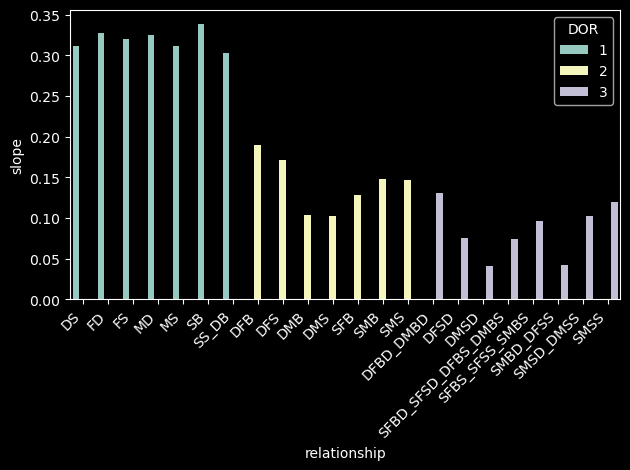

In [8]:
sns.barplot(
    data=df_frreg,
    x="relationship",
    y="slope",
    hue="DOR"
)

plt.xticks(rotation=45, ha="right")  # x축 레이블 45도 회전 및 오른쪽 정렬

plt.tight_layout();  # 레이아웃 조정 (필요에 따라 추가)
plt.show()

In [9]:
# UKB
source = "GS"
for fn in fns[source]:
    df_frreg = pd.read_csv(f"{frreg_paths[source]}/{fn}", sep='\t')
    df_frreg
    break

In [10]:
df_frreg.groupby("DOR")[["slope", "n"]].agg(["mean", "std", "size"])

slope                           n                  
         mean       std size         mean          std size
DOR                                                        
1    0.130430  0.087607    7  5200.857143  1795.756055    7
2    0.017402  0.140637   30   517.800000   437.075343   30
3    0.048197  0.303927   29   188.068966   175.498053   29

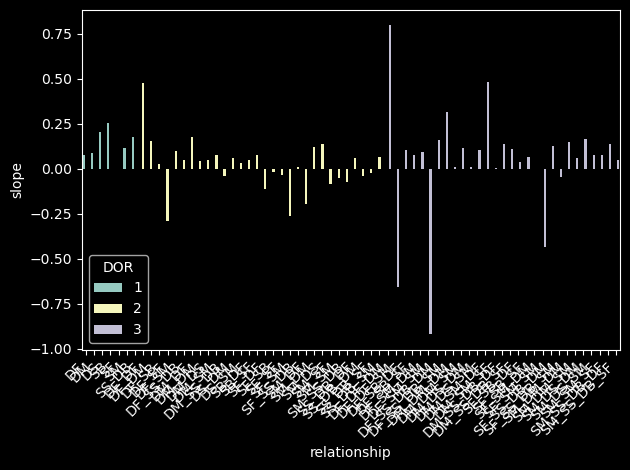

In [11]:
sns.barplot(
    data=df_frreg,
    x="relationship",
    y="slope",
    hue="DOR"
)

plt.xticks(rotation=45, ha="right")  # x축 레이블 45도 회전 및 오른쪽 정렬
plt.tight_layout();  # 레이아웃 조정 (필요에 따라 추가)
plt.show()

UKB는 DOR마다 절반씩 줄어드는것 같은데, GS는 굉장히 hetero.

- DOR=1은 GS가 많은것 같고,
- DOR=3은 UKB가 많긴 한데, GS가 relationship 종류는 더 많음.

비슷한 phenotype으로 보면...?

In [12]:
# UKB : FEV1__FVC_ratio_Z-score
# GS : ratio

In [13]:
# UKB
source = "UKB"
for fn in fns[source]:
    if fn.split(".")[0] == "FEV1__FVC_ratio_Z-score":
        df_frreg = pd.read_csv(f"{frreg_paths[source]}/{fn}", sep='\t')

In [14]:
df_frreg.groupby("DOR")[["slope", "n"]].agg(["mean", "std", "size"])

slope                           n                  
         mean       std size         mean          std size
DOR                                                        
1    0.197283  0.048257    7  1955.428571  1302.885881    7
2    0.074693  0.124712    7   435.142857   231.187823    7
3    0.052330  0.038981    8  2347.250000  2353.841829    8

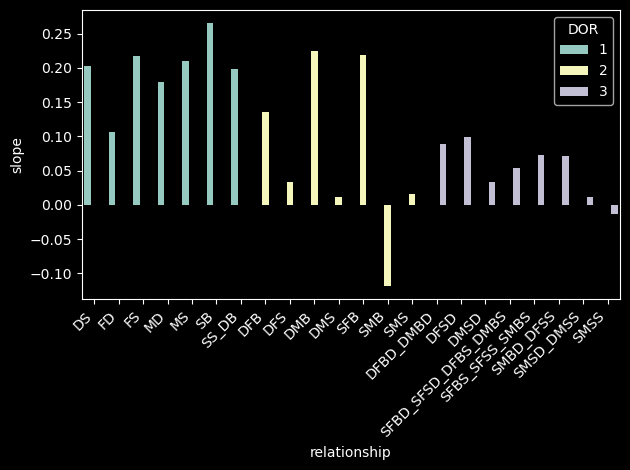

In [15]:
sns.barplot(
    data=df_frreg,
    x="relationship",
    y="slope",
    hue="DOR"
)

plt.xticks(rotation=45, ha="right")  # x축 레이블 45도 회전 및 오른쪽 정렬

plt.tight_layout();  # 레이아웃 조정 (필요에 따라 추가)
plt.show()

In [16]:
# GS
source = "GS"
for fn in fns[source]:
    if fn.split(".")[0] == "ratio":
        df_frreg = pd.read_csv(f"{frreg_paths[source]}/{fn}", sep='\t')

In [17]:
df_frreg.groupby("DOR")[["slope", "n"]].agg(["mean", "std", "size"])

slope                           n                  
         mean       std size         mean          std size
DOR                                                        
1    0.094145  0.029625    7  3782.000000  1305.045082    7
2    0.058904  0.135002   30   359.666667   313.774830   30
3    0.023554  0.197227   24   153.000000   120.165104   24

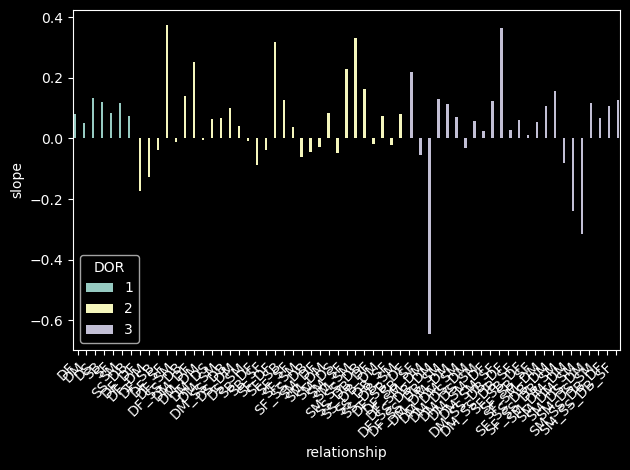

In [18]:
sns.barplot(
    data=df_frreg,
    x="relationship",
    y="slope",
    hue="DOR"
)

plt.xticks(rotation=45, ha="right")  # x축 레이블 45도 회전 및 오른쪽 정렬
plt.tight_layout();  # 레이아웃 조정 (필요에 따라 추가)
plt.show()

흠... 비슷한거같긴 한데.... 

In [20]:
df_frreg.groupby("DOR").size()

DOR
1     7
2    30
3    24
dtype: int64

In [22]:
df_frreg.groupby(["DOR", "sex_type", "Erx"]).size()

DOR  sex_type  Erx     
1    FF        0.500000    1
               0.750000    1
     FM        0.353553    1
               0.707107    2
     MM        0.000000    1
               0.500000    1
2    FF        0.250000    2
               0.250000    1
               0.375000    2
               0.500000    3
     FM        0.000000    6
               0.176777    2
               0.353553    6
               0.530330    2
     MM        0.000000    3
               0.250000    2
               0.500000    1
3    FF        0.125000    2
               0.125000    1
               0.187500    1
               0.250000    3
     FM        0.000000    6
               0.176777    4
               0.265165    2
     MM        0.000000    3
               0.250000    1
               0.375000    1
dtype: int64

## appropriate weight depending on number of relationship

In [ ]:
for ii, fn in enumerate(tqdm(fns)):
    pheno = fn.split(".")[0]
    print(f"[{ii+1}/{len(fns)}] {pheno}")
    
    # load FR-reg results
    df_frreg = pd.read_csv(f"{frreg_path}/{fn}", 
                           delim_whitespace=True)
    df_x = obj2.estimateX(df_frreg,
                          n_resample=100,
                          alpha_dicts={"type": "eta", "weight":-3},
                          regout_bin=["DOR", "sex_type"])
    
    if df_x.shape[0] > 0:
        # save raw results
        df_x.to_csv(f"{output_path}/{pheno}.X_raw",
                    sep='\t',
                    index=False)
        tools.raw2long(df_x, params=["eta", "alpha", "X"]).to_csv(
            f"{output_path}/{pheno}.X",
            sep='\t',
            index=False)

In [ ]:
"QTC_interval"